# Next.js——React 之上的生产级框架

## 框架的代价

上一节发布到公网后，打开个人主页，进入浏览器开发者工具的 Network（网络）面板，刷新网页，可以看到这样的加载顺序：

1. 浏览器先下载几乎为空的 index.html，body 里只有一个空的 root 节点。
2. 浏览器再下载 html 依赖的 index-[hash].js 和 css。
3. JavaScript 执行后，React 才在浏览器中把页面内容画出来。

这是一种客户端渲染的典型过程：服务器发送“HTML 空壳 + JavaScript 包”，最终内容由浏览器执行 JavaScript 后生成。它会带来三个问题：

- **直接访问 /text-lab 可能 404**：服务器的磁盘上没有 text-lab 文件，文字实验室只是 JavaScript 在浏览器里临时画出来的页面。必须先进入首页再点击导航；直接输入子路径或刷新子路径时容易暴露这个问题。
- **首屏会慢一拍**：先下载空壳，再下载 JS，最后执行并绘制页面。网络较慢时，访客会先看到白屏。
- **对 SEO 不友好**：爬虫拿到的 index.html 没有实际内容；如果爬虫不执行或不能完整执行 JavaScript，它看到的就是一个空页面。

SEO:搜索引擎优化，让网站在搜索引擎的排名更靠前，搜索引擎会派爬虫来抓页面

三个问题的共同根源是：页面不是服务器上的真实 HTML 文件，而是浏览器临时根据 JS 算出来的。

解决思路是提前把每一页“画好”，生成真实 HTML 文件放在服务器上。这样子路径有真实页面、访客可以更快看到内容，搜索引擎也能直接读取页面内容。手动搭建这套流程很麻烦，Next.js 就是用框架约定把它标准化。

## Next.js 是什么

Next.js 是 React 之上的生产级框架。React 主要负责组件和界面，Next.js 再补上完整 Web 应用上线需要的能力，例如：

- 路由：哪个 URL 对应哪一页。
- 预渲染：提前生成真实 HTML，改善首屏速度和 SEO。

在 Next.js 出现以前，路由可以使用 react-router，但它本身不会自动把页面变成服务器上的 HTML；预渲染则需要自己搭 Node 服务器、手动把 React 渲染成 HTML 字符串、配置两端路由和数据获取。Next.js 用约定把这些重复的工程工作统一起来。

## 看一看一个真实的 Next.js 项目

课程提供了已经迁移好的 Demo：zero-to-tech-4-5。

### package.json 的变化

4.5 的 Next.js 项目大致是：

```json
{
  "dependencies": {
    "animejs": "^4.4.1",
    "react": "^19.2.6",
    "react-dom": "^19.2.6",
    "next": "^15.0.0"
  },
  "scripts": {
    "dev": "next dev",
    "build": "next build",
    "start": "next start"
  }
}
```

4.4 的 Vite + React 项目则是：

```json
{
  "dependencies": {
    "animejs": "^4.4.1",
    "react": "^19.2.6",
    "react-dom": "^19.2.6"
  },
  "scripts": {
    "dev": "vite",
    "build": "vite build",
    "preview": "vite preview"
  }
}
```

变化有三点：

- dependencies 多了 next。
- dev 和 build 命令名字没变，但背后的执行者从 Vite 换成了 Next。
- Vite 的 preview 换成了 Next 的 start，用于用构建产物启动本地生产服务。

Next.js 自带构建工具，所以这个项目不再需要 Vite。

还存在很多不使用 Next 的纯 React 或 Vue 工程使用 Vite。

运行 npm run dev 时，Next.js 还会提供开发期错误提示。页面左下角有标志

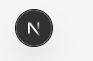

在代码出错时可以展开完整报错，方便复制给 AI 或自己定位。

## 用文件夹结构来管理网站结构

打开 zero-to-tech-4-4 和 zero-to-tech-4-5 对比，可以把关键结构看成这样：

```text
zero-to-tech-4-4/                zero-to-tech-4-5/
  src/                             app/                       ← Next.js 的“页面区”
    main.jsx                         layout.jsx               ← 全站外壳（页面包裹 + 引入 css）
    App.jsx           ← 这一坨        page.jsx                 ← / 这一页
    router/                          text-lab/
      useRoute.js     ← 手搓 26 行      page.jsx               ← /text-lab 这一页
    components/                    components/
      Nav.jsx                        Nav.jsx
      HomePage.jsx                   HomeView.jsx
      TextLabPage.jsx                TextLabView.jsx
      AnimatedCardGrid.jsx           AnimatedCardGrid.jsx
    data/                          data/
      site.js                        site.js                  ← 一字未改

```

4.5 的 site.js 内容表基本不变，组件也大量复用；变化最大的是路由和入口：

- src 目录，index.html 文件消失了
- src 下的 css , data , components 移到了项目根目录
- 技术栈改变，配置文件由 vite.config.js 变为 next.config.mjs
- 新增 app/ 目录，用来管理 URL。
- app/layout.jsx 是全站外壳，负责页面包裹和全局 CSS。
- app/page.jsx 对应网站根路径的网页。
- app/text-lab/page.jsx 对应 text-lab 网页。

page.jsx 文件既实现了管理路由，又直接是页面文件

### 文件夹就是路由

若想增加 /blog 页面，只需要新建：

```text
app/blog/page.jsx
```

Next.js 按约定把它接到 /blog，不用单独注册路由表。这就是“约定优于配置”：只要文件夹和文件按约定摆好，URL 与页面的关系就自动建立。

4.4 中“把当前页面写进 URL”的数据驱动思想没有改变，改变的是读写 URL、监听变化和选择页面的工作从手写代码交给了 Next.js。

## 页面文件可以很薄

page.jsx 的职责只是声明：该 URL 要渲染哪个页面组件。

```jsx
import TextLabView from "../../components/TextLabView.jsx";

export default function Page() {
  return <TextLabView />;
}
```

页面文件只有几行，路由、刷新、浏览器前进后退等工作由 Next.js 处理。首页 page.jsx 也可以用同样的方式渲染首页组件。

这种结构把“页面地址”和“页面内容”分开：app 目录负责路由位置，components 目录负责可复用界面，页面文件负责把两者连接起来。

## React 组件（components）的变化

迁移到 Next.js 后，大部分组件和 4.4 几乎一样，但有两个值得认识的变化。

### 导航使用 Next 的 Link

Nav 组件不再依赖 4.4 的手写路由逻辑，而是使用 Next 提供的 <Link> 标签完成站内导航。它让框架接管页面跳转，不需要在 App.jsx 里自己判断当前页面。

```jsx
import Link from "next/link";

export default function Nav() {
  return <Link href="/text-lab">文字实验室</Link>;
}
```

这里只需记住：站内链接交给框架的 Link；不用重新实现一套路由。

### use client：客户端组件开关

有些组件文件顶部会写：

```jsx
"use client";
```

课程 Demo 中，带有这行的通常是需要在浏览器里动起来的组件，例如：

- Nav.jsx：导航切换和当前路径高亮。
- InputCard.jsx：输入框和字数统计。
- ResultCard.jsx：结果卡片交互或入场效果。
- AnimatedCardGrid.jsx：卡片飞入动画。

这些组件用到了 useState、useEffect、usePathname 等需要浏览器环境的能力,叫**客户端组件**。

没有 "use client" 的组件默认是**服务端组件**（Server Component），例如纯展示的 HomeView.jsx、TextLabView.jsx、PageHeading.jsx 和 app/ 下的页面文件。它们可以在服务器或构建阶段先生成 HTML。

要注意：客户端组件也可以先被预渲染成 HTML。"use client" 并不表示“不预渲染”，而是表示除了预渲染的 HTML，还要把相关 JavaScript 发送到浏览器，让组件在浏览器中接管交互。可以这样记：

- 服务端组件：偏向纯展示，服务器或构建阶段生成 HTML。
- 客户端组件：仍可预渲染，但还会额外发送 JS，使点击、输入和动画生效。

服务端组件还可以进一步在请求到达时生成动态内容，但这是更深入的数据获取方式，本节只先认识概念。

## 构建 Next.js 项目

在 zero-to-tech-4-5 目录执行：

```bash
npm run build
```

构建输出会列出每条路由，例如：

```text
Route (app)                       Size    First Load JS
┌ ○ /                            486 B    120 kB
├ ○ /_not-found                  996 B    103 kB
└ ○ /text-lab                    1.19 kB  117 kB

○ (Static) prerendered as static content
表示 / 和 /text-lab 已在构建阶段预渲染为静态内容，还加了一个找不到网页的情况
```

课程中还可以在构建产物目录看到对应的页面文件：

```text
.next/server/app/
├── index.html
├── _not-found.html
└── text-lab.html
```

这说明 Next.js 已经把页面从“浏览器临时根据 JS 计算”变成了构建阶段生成的 HTML，直接访问、首屏显示和 SEO 都得到改善。

.next/server/app/ 下的文件不能简单照搬 4.2 的 dist/ 交给 Nginx 当普通静态目录。Next 的完整生产运行通常需要它自己的 Node 服务，部署在下一节讲。

## 把现有项目改造成 Next.js

课程 Demo 已经准备好完整的 zero-to-tech-4-5/。迁移自己的 zero-to-tech 时，可以直接采用 Demo 的目录结构：

1. 保留项目根目录的隐藏 .git 目录，它记录 GitHub 远程地址和提交历史。
2. 删除项目中除 .git 以外的旧项目文件。
3. 把 zero-to-tech-4-5/ 中的项目文件复制进来。
4. 不要复制 node_modules/ 和 .next/ 等可重新生成的产物,和 .vscode/ 文件夹。
5. 进入项目目录，重新安装依赖并启动：

```bash
npm install
npm run dev
npm run build
```

确认页面正常后，再提交并推送：

```bash
git add .
git commit -m "migrate project to Next.js"
git push
```

## 从 0 新建一个 Next 项目

如果不是迁移已有项目，而是从空白开始，可以直接使用：

```bash
npm create next-app@latest
```

命令会交互式询问项目名称、是否使用 TypeScript、是否使用 ESLint、是否使用 Tailwind CSS 等选项。

### 认识 Tailwind CSS

Tailwind CSS 是一种工具类样式方案。它把常用样式拆成 class，直接写在 JSX 的 className 中，例如：

```jsx
<div className="flex items-center gap-4 rounded-xl bg-white p-6">
  内容
</div>
```

本课程的 Demo 没有选择 Tailwind，是为了保持前面项目的外观和 CSS 文件。当前不需要深入学习 Tailwind，但要认得它；让 AI 编写前端时，可以用 Tailwind 让AI选择合适的样式。

## 核心概念回顾

- **Next.js 是 React 之上的生产级框架**：React 管组件，Next.js 管路由、构建、预渲染等完整应用能力。
- **文件夹就是路由**：app/text-lab/page.jsx 自动对应 /text-lab，不用注册路由。
- **跳转交给框架**：使用 Next 的 <Link> 方式，让 App.jsx + useRoute.js 这套手写路由整体消失。
- **页面会被预渲染成 HTML**：npm run build 在构建阶段生成页面，改善直接访问、首屏加载和 SEO。
- **"use client" 是交互边界**：需要 state、effect、路径读取或动画的组件标记为客户端组件；纯展示组件默认是服务端组件。
- **Next 项目需要自己的生产启动方式**：构建后用 npm run start 启动 Next 服务，不能把 .next/server/app/ 当成 Vite 的 dist/ 直接交给 Nginx。